In [1]:
import os
import glob
import json
import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as cl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pandas as pd
from collections import defaultdict
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    f1_score,
    cohen_kappa_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
)


In [2]:
def safe_cw_auc(targets, scores, mode = 'ovo', count_lim = 2):
    unique_targets, counts = np.unique(targets, return_counts=True)
    unique_targets = unique_targets[counts > count_lim]
    cw_auc = np.full(scores.shape[-1], np.nan)
    if len(unique_targets) == 1:
        return cw_auc
    for k in unique_targets:
        if mode == 'ovo':
            cw_auc[k] = 0
            for l in unique_targets:
                if l == k: continue
                tmp_mask = np.logical_or(targets == k, targets == l)
                tmp_targets = targets[tmp_mask]
                tmp_scores = scores[tmp_mask, k]
                cw_auc_kvl = roc_auc_score(tmp_targets == k,tmp_scores)
                cw_auc[k] += cw_auc_kvl/(len(unique_targets -1))
        elif mode == 'ovr':
            cw_auc[k] = roc_auc_score(targets == k, scores[:, k])
        else:
            raise "Mode must be ovo or ovr"
    return cw_auc

def safe_cw_pr_re_f1(targets, preds, num_classes, count_lim = 2):
    unique_targets, counts = np.unique(targets, return_counts=True)

    # Target count filter
    count_filt = np.full(num_classes, np.nan)
    count_filt[unique_targets[counts > count_lim]] = 1 

    # Calculate scores (results will only include present targets)
    cw_prec = precision_score(targets, preds, average=None, zero_division=np.nan)
    cw_rec = recall_score(targets, preds, average=None, zero_division=np.nan)
    cw_f1 = f1_score(targets, preds, average=None, zero_division=np.nan)

    # Initialize NaN arrays to fill to make sure all possible targets are representet
    cw_prec_array = np.full(num_classes, np.nan)
    cw_rec_array = np.full(num_classes, np.nan)
    cw_f1_array = np.full(num_classes, np.nan)

    # Fill in NaN arrays
    for i, k in enumerate(unique_targets):
        cw_prec_array[k] = cw_prec[i] * count_filt[i]
        cw_rec_array[k] = cw_rec[i] * count_filt[i]
        cw_f1_array[k] = cw_f1[i] * count_filt[i]

    return cw_prec_array, cw_rec_array, cw_f1_array

def h5_to_dict(h5_path):
    data = defaultdict(dict)
    with h5py.File(h5_path, 'r') as f:
        data['start_time'] = f.attrs['start_time']

        if 'ahi' in f.attrs.keys():
            data['ahi'] = f.attrs['ahi']
        
        if np.any([f'{stage}_hours' in f.attrs.keys() for stage in ['wake', 'n1', 'n2', 'n3', 'rem']]):
            stages = {
                'wake': 0,
                'n1': 0,
                'n2': 0,
                'n3': 0,
                'rem': 0,
                'missing': 0,
            }

            for stage in stages.keys():
                if f'{stage}_hours' in f.attrs.keys():
                    stages[stage] = f.attrs[f'{stage}_hours']
            data['stages_hours'] = stages
        
        data['accelerometry'] = np.array(f['data/accelerometry'])
        data['hypnogram'] = np.array(f['annotations/hypnogram'])

    return data


In [27]:
ss_labels_name = 'light_deep_rem'
ss_label_map = {
    'deep': 0,
    'light': 1,
    'rem': 2,
    'wake': 3,
    'missing': -9,
}
# ss_label_map_inv = {val: key for key, val in ss_label_map.items()}
ss_label_map_inv = {val: key for key, val in ss_label_map.items() if val != -9}
ss_label_order = ['wake', 'light', 'deep', 'rem']
ss_label_name = ['Wake', 'Light', 'Deep', 'REM']

ss_colormap = {
    'wake': 'tab:red',
    'Wake': 'tab:red',
    'light': 'tab:orange',
    'Light': 'tab:orange',
    'deep': 'tab:blue',
    'Deep': 'tab:blue',
    'rem': 'tab:green',
    'REM': 'tab:green',
}
ss_case_map = {
    'wake':'Wake',
    'light': 'Light',
    'deep': 'Deep',
    'rem': 'REM',
}

dset_map = {
    'newcastle_left': 'Newcastle',
    'newcastle_right': 'Newcastle',
    'stages': 'STAGES',
    'dreamt': 'DREAMT',
    'tbi': 'TBI',
    'amazfit': 'Health'
}
dset_order_nomap = ['stages', 'dreamt', 'tbi']
dset_order = ['STAGES', 'DREAMT', 'TBI']

paths = {
    'TBI': '/oak/stanford/groups/mignot/projects/actigraphy_fm/data/tbi/',
    'Amazfit': '/oak/stanford/groups/mignot/projects/actigraphy_fm/data/amazfit/',
    'DREAMT': '/oak/stanford/groups/mignot/projects/actigraphy_fm/data/dreamt/',
    'STAGES': '/oak/stanford/groups/mignot/projects/actigraphy_fm/data/stages/',
    'Newcastle L': '/oak/stanford/groups/mignot/projects/actigraphy_fm/data/newcastle_left/',
    'Newcastle R': '/oak/stanford/groups/mignot/projects/actigraphy_fm/data/newcastle_right/',
    'sleepaccel': '/oak/stanford/groups/mignot/projects/actigraphy_fm/data/sleepaccel/',
}

apnea_labels_name = 'apnea'
label_map = {
    'none': 0,
    'ha': 1,
    'oa': 2,
    'ca': 2,
}
label_map_inv = {val: key for key, val in label_map.items()}
label_order = ['none', 'ha', 'oa']
label_names = ['None', 'HA', 'OA/CA']

colormap = {
    'none': 'white',
    'ha': 'tab:olive',
    'oa': 'tab:purple',
}

# RE maps
label_map_re = {
    'None': 0,
    'RE': 1,
}
label_map_re_inv = {
    0: 'None',
    1: 'RE',
    2: 'RE',
}
label_order_re = ['None', 'RE']
label_names_re = ['None', 'RE']

colormap_re = {
    'None': 'white',
    'RE': 'tab:purple',
}


In [5]:
## Subject-wise performance metrics
experiment = 'baseline'

cw_precs = defaultdict(list)
cw_recalls = defaultdict(list)
cw_f1s = defaultdict(list)

cw_aucs = defaultdict(list)
roc_curves = defaultdict(list)
soft_preds_all = []
targets_all = []
preds_all = []

macro_results = defaultdict(list)
summary_diffs = defaultdict(list)
summary_means = defaultdict(list)

cw_precs_re = defaultdict(list)
cw_recalls_re = defaultdict(list)
cw_f1s_re = defaultdict(list)
macro_results_re = defaultdict(list)
soft_preds_all_re = []
targets_all_re = []
preds_all_re = []

exp_i = []
subject_i = []
dataset_i = []
'''/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_lstmc_apnea_wa_internal/dreamt/S004
/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_lstmc_internal/dreamt/S004'''
if experiment == '2c':
    ## Two class experiments
    lmstc_apnea_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_lstmc_apnea_2c_internal'
    lin_apnea_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/mae_bwm_apnea_2c_internal'

    lm_inv = label_map_re_inv

elif experiment == 'wa':
    ## 3 class weight adjusted
    lmstc_apnea_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_lstmc_apnea_wa_internal'
    lin_apnea_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_apnea_wa_internal'

    lm_inv = label_map_inv

elif experiment == 'reg':
    lstmc_apnea_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_lstmc_apnea_reg_internal'
    lin_apnea_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_apnea_reg_internal'

elif experiment == 'baseline':
    ## 3 class unadjusted
    lmstc_apnea_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_lstmc_apnea_internal'
    lin_apnea_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_apnea_internal'

    lm_inv = label_map_inv

lmstc_sleepstage_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_lstmc_internal'
lin_sleepstage_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_internal'

external_apnea_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/mae_bwm_apnea_2c_external'
external_sleep_stage_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_external_2'
lm_inv = label_map_re_inv

experiments = [('External Test', external_apnea_path, external_sleep_stage_path)]#('LSTM-C', lmstc_apnea_path, lmstc_sleepstage_path), ('Linear', lin_apnea_path, lin_sleepstage_path)]
for exp_name, experiment_dir, sleepstage_dir in experiments:
    for dataset in os.scandir(experiment_dir):
        for sub_dir in os.scandir(dataset):
            # ss_results_path = os.path.join(sleepstage_dir, os.path.basename(dataset), os.path.basename(sub_dir))

            subject_i.append(os.path.basename(sub_dir))
            dataset_i.append(os.path.basename(dataset))
            exp_i.append(exp_name)
            
            scores = np.load(os.path.join(sub_dir.path, 'soft_preds.npy'))
            targets = np.load(os.path.join(sub_dir.path, 'targets.npy'))
            
            
            # Get hard predictions
            preds = scores.argmax(axis=-1)

            soft_preds_all.append(np.copy(scores))
            targets_all.append(np.copy(targets))
            preds_all.append(np.copy(preds))

            unique_targets, counts = np.unique(targets, return_counts=True)
            unique_preds, pred_counts = np.unique(preds, return_counts=True)

            ## Subject-wise class-wise scores
            # Precision, Recall, and F1
            cw_pr, cw_re, cw_f1 = safe_cw_pr_re_f1(targets, preds, num_classes=scores.shape[-1], count_lim=3)
            
            # Manually compute binary AUC for each label present (NaN for non-valid)
            cw_auc = safe_cw_auc(targets, scores, mode='ovr', count_lim=3)

            for k in range(scores.shape[-1]):
                cw_aucs[lm_inv[k]].append(float(cw_auc[k]))
                cw_precs[lm_inv[k]].append(float(cw_pr[k]))
                cw_recalls[lm_inv[k]].append(float(cw_re[k]))
                cw_f1s[lm_inv[k]].append(float(cw_f1[k]))

            # Class-wise ROC curves
            for k in unique_targets:
                roc = roc_curve(targets, scores[:,k], pos_label=k)
                roc_curves[lm_inv[k]].append(roc)
            
            ## Subject-wise macro averages
            mac_prec = precision_score(targets, preds, average='macro', zero_division=np.nan)
            mac_rec = recall_score(targets, preds, average='macro', zero_division=np.nan)
            mac_f1 = f1_score(targets, preds, average='macro', zero_division=np.nan)
            kappa = cohen_kappa_score(targets, preds)
            macro_results['Precision'].append(mac_prec)
            macro_results['Recall'].append(mac_rec)
            macro_results['F1'].append(mac_f1)
            macro_results['Kappa'].append(kappa)
            macro_results['AUROC'].append(np.nanmean(cw_auc))
            
            if experiment != '2c':
                ### RE label set evaluation
                preds[preds==2] = 1
                targets[targets==2] = 1
        

                soft_preds_all_re.append(np.copy(scores))
                targets_all_re.append(np.copy(targets))
                preds_all_re.append(np.copy(preds))

                ## Subject-wise macro averages
                mac_prec = precision_score(targets, preds, average='macro', zero_division=np.nan)
                mac_rec = recall_score(targets, preds, average='macro', zero_division=np.nan)
                mac_f1 = f1_score(targets, preds, average='macro', zero_division=np.nan)
                kappa = cohen_kappa_score(targets, preds)
                macro_results_re['Precision'].append(mac_prec)
                macro_results_re['Recall'].append(mac_rec)
                macro_results_re['F1'].append(mac_f1)
                macro_results_re['Kappa'].append(kappa)

                cw_pr, cw_re, cw_f1 = safe_cw_pr_re_f1(targets, preds, num_classes=2, count_lim=3)
                for k in range(2):
                    cw_precs_re[label_map_re_inv[k]].append(float(cw_pr[k]))
                    cw_recalls_re[label_map_re_inv[k]].append(float(cw_re[k]))
                    cw_f1s_re[label_map_re_inv[k]].append(float(cw_f1[k]))

macro_results = pd.DataFrame(data=macro_results)
cw_aucs = pd.DataFrame(data=cw_aucs)
cw_precs = pd.DataFrame(data=cw_precs)
cw_recalls = pd.DataFrame(data=cw_recalls)
cw_f1s = pd.DataFrame(data=cw_f1s)
macro_results_re = pd.DataFrame(data=macro_results_re)
cw_precs_re = pd.DataFrame(data=cw_precs_re)
cw_recalls_re = pd.DataFrame(data=cw_recalls_re)
cw_f1s_re = pd.DataFrame(data=cw_f1s_re)

/tmp/ipykernel_14292/3888297159.py:114: RuntimeWarning: Mean of empty slice
  macro_results['AUROC'].append(np.nanmean(cw_auc))
/tmp/ipykernel_14292/3888297159.py:114: RuntimeWarning: Mean of empty slice
  macro_results['AUROC'].append(np.nanmean(cw_auc))


In [6]:
macro_table = macro_results.copy()
macro_table['Model'] = exp_i
macro_table['Dataset'] = dataset_i
macro_table['Dataset'] = macro_table['Dataset'].map(dset_map)

macro_table_overall = macro_table.copy()
macro_table_overall['Dataset'] = 'Overall'
overall_notbi = macro_table_overall[macro_table['Dataset'] != 'TBI'].copy()
overall_notbi['Dataset'] = 'Overall w/o TBI'
macro_table = pd.concat([macro_table, macro_table_overall, overall_notbi])

sd_df = macro_table.groupby(['Dataset', 'Model']).std()
mean_df = macro_table.groupby(['Dataset', 'Model']).mean()
new_df = mean_df.round(3).astype(str) + " ± " + sd_df.round(3).astype(str)
# new_df.to_csv('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/tp_macro_results.csv')
overall = new_df.loc[['Overall w/o TBI','Overall']]
rest = new_df.drop(['Overall w/o TBI','Overall'], level="Dataset")
new_df = pd.concat([rest, overall])
new_df

,,Precision,Recall,F1,Kappa,AUROC
Dataset,Model,,,,,
Overall w/o TBI,External Test,0.545 ± 0.057,0.642 ± 0.113,0.514 ± 0.084,0.105 ± 0.124,0.719 ± 0.127
Overall,External Test,0.545 ± 0.057,0.642 ± 0.113,0.514 ± 0.084,0.105 ± 0.124,0.719 ± 0.127


In [7]:
cw_f1s['Score'] = 'F1'
cw_precs['Score'] = 'Precision'
cw_recalls['Score'] = 'Recall'
cw_aucs['Score'] = 'AUROC'
for table in [cw_f1s, cw_precs, cw_recalls, cw_aucs]:
    table['Model'] = exp_i
    table['Dataset'] = dataset_i
    table['Dataset'] = table['Dataset'].map(dset_map)
cw_scores = pd.concat([cw_f1s, cw_precs, cw_recalls, cw_aucs]).rename(columns=ss_case_map)
table = cw_scores.copy()
    
table_overall = table.copy()
table_overall['Dataset'] = 'Overall'
table = pd.concat([table, table_overall])

sd_df = table.groupby(['Dataset','Score','Model']).std()
mean_df = table.groupby(['Dataset', 'Score','Model']).mean()
new_df = mean_df.round(3).astype(str) + " ± " + sd_df.round(3).astype(str)
# new_df.to_csv('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/tp_macro_results.csv')
overall = new_df.loc[['Overall']]
rest = new_df.drop('Overall', level="Dataset")
new_df = pd.concat([rest, overall])
# new_df.loc[['Health']]
new_df

None             RE
Dataset Score     Model                                      
Overall AUROC     External Test  0.719 ± 0.127  0.719 ± 0.127
        F1        External Test  0.854 ± 0.103  0.185 ± 0.178
        Precision External Test  0.965 ± 0.051  0.131 ± 0.146
        Recall    External Test  0.776 ± 0.137  0.489 ± 0.265

In [46]:
cw_f1s_re['Score'] = 'F1'
cw_precs_re['Score'] = 'Precision'
cw_recalls_re['Score'] = 'Recall'
for table in [cw_f1s_re, cw_precs_re, cw_recalls_re]:
    table['Model'] = exp_i
    table['Dataset'] = dataset_i
    table['Dataset'] = table['Dataset'].map(dset_map)
cw_scores = pd.concat([cw_f1s_re, cw_precs_re, cw_recalls_re])#.rename(columns=ss_case_map)
table = cw_scores.copy()
    
table_overall = table.copy()
table_overall['Dataset'] = 'Overall'
table = pd.concat([table, table_overall])

sd_df = table.groupby(['Dataset','Score','Model']).std()
mean_df = table.groupby(['Dataset', 'Score','Model']).mean()
new_df = mean_df.round(3).astype(str) + " ± " + sd_df.round(3).astype(str)
# new_df.to_csv('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/tp_macro_results.csv')
overall = new_df.loc[['Overall']]
rest = new_df.drop('Overall', level="Dataset")
new_df = pd.concat([rest, overall])
# new_df.loc[['Health']]
new_df

None             RE
Dataset Score     Model                               
DREAMT  F1        LSTM-C  0.611 ± 0.237  0.248 ± 0.191
                  Linear  0.616 ± 0.205  0.255 ± 0.196
        Precision LSTM-C  0.945 ± 0.106  0.174 ± 0.154
                  Linear  0.943 ± 0.104  0.176 ± 0.159
        Recall    LSTM-C  0.498 ± 0.249  0.772 ± 0.248
                  Linear    0.49 ± 0.21  0.793 ± 0.191
STAGES  F1        LSTM-C  0.661 ± 0.162  0.124 ± 0.124
                  Linear  0.581 ± 0.106  0.117 ± 0.118
        Precision LSTM-C  0.969 ± 0.036  0.079 ± 0.092
                  Linear  0.971 ± 0.037  0.071 ± 0.083
        Recall    LSTM-C  0.526 ± 0.186  0.633 ± 0.204
                  Linear   0.424 ± 0.11   0.72 ± 0.171
TBI     F1        LSTM-C  0.666 ± 0.242  0.119 ± 0.082
                  Linear  0.732 ± 0.189  0.128 ± 0.088
        Precision LSTM-C  0.978 ± 0.029  0.068 ± 0.051
                  Linear  0.975 ± 0.029  0.074 ± 0.058
        Recall    LSTM-C  0.549 ± 0.253   0.697 ± 0.25
                  Linear  0.615 ± 0.207  0.653 ± 0.198
Overall F1        LSTM-C  0.639 ± 0.229  0.178 ± 0.159
                  Linear  0.654 ± 0.196  0.184 ± 0.163
        Precision LSTM-C  0.961 ± 0.077  0.118 ± 0.125
                  Linear   0.96 ± 0.076   0.12 ± 0.128
        Recall    LSTM-C  0.521 ± 0.242  0.721 ± 0.246
                  Linear  0.527 ± 0.209    0.727 ± 0.2

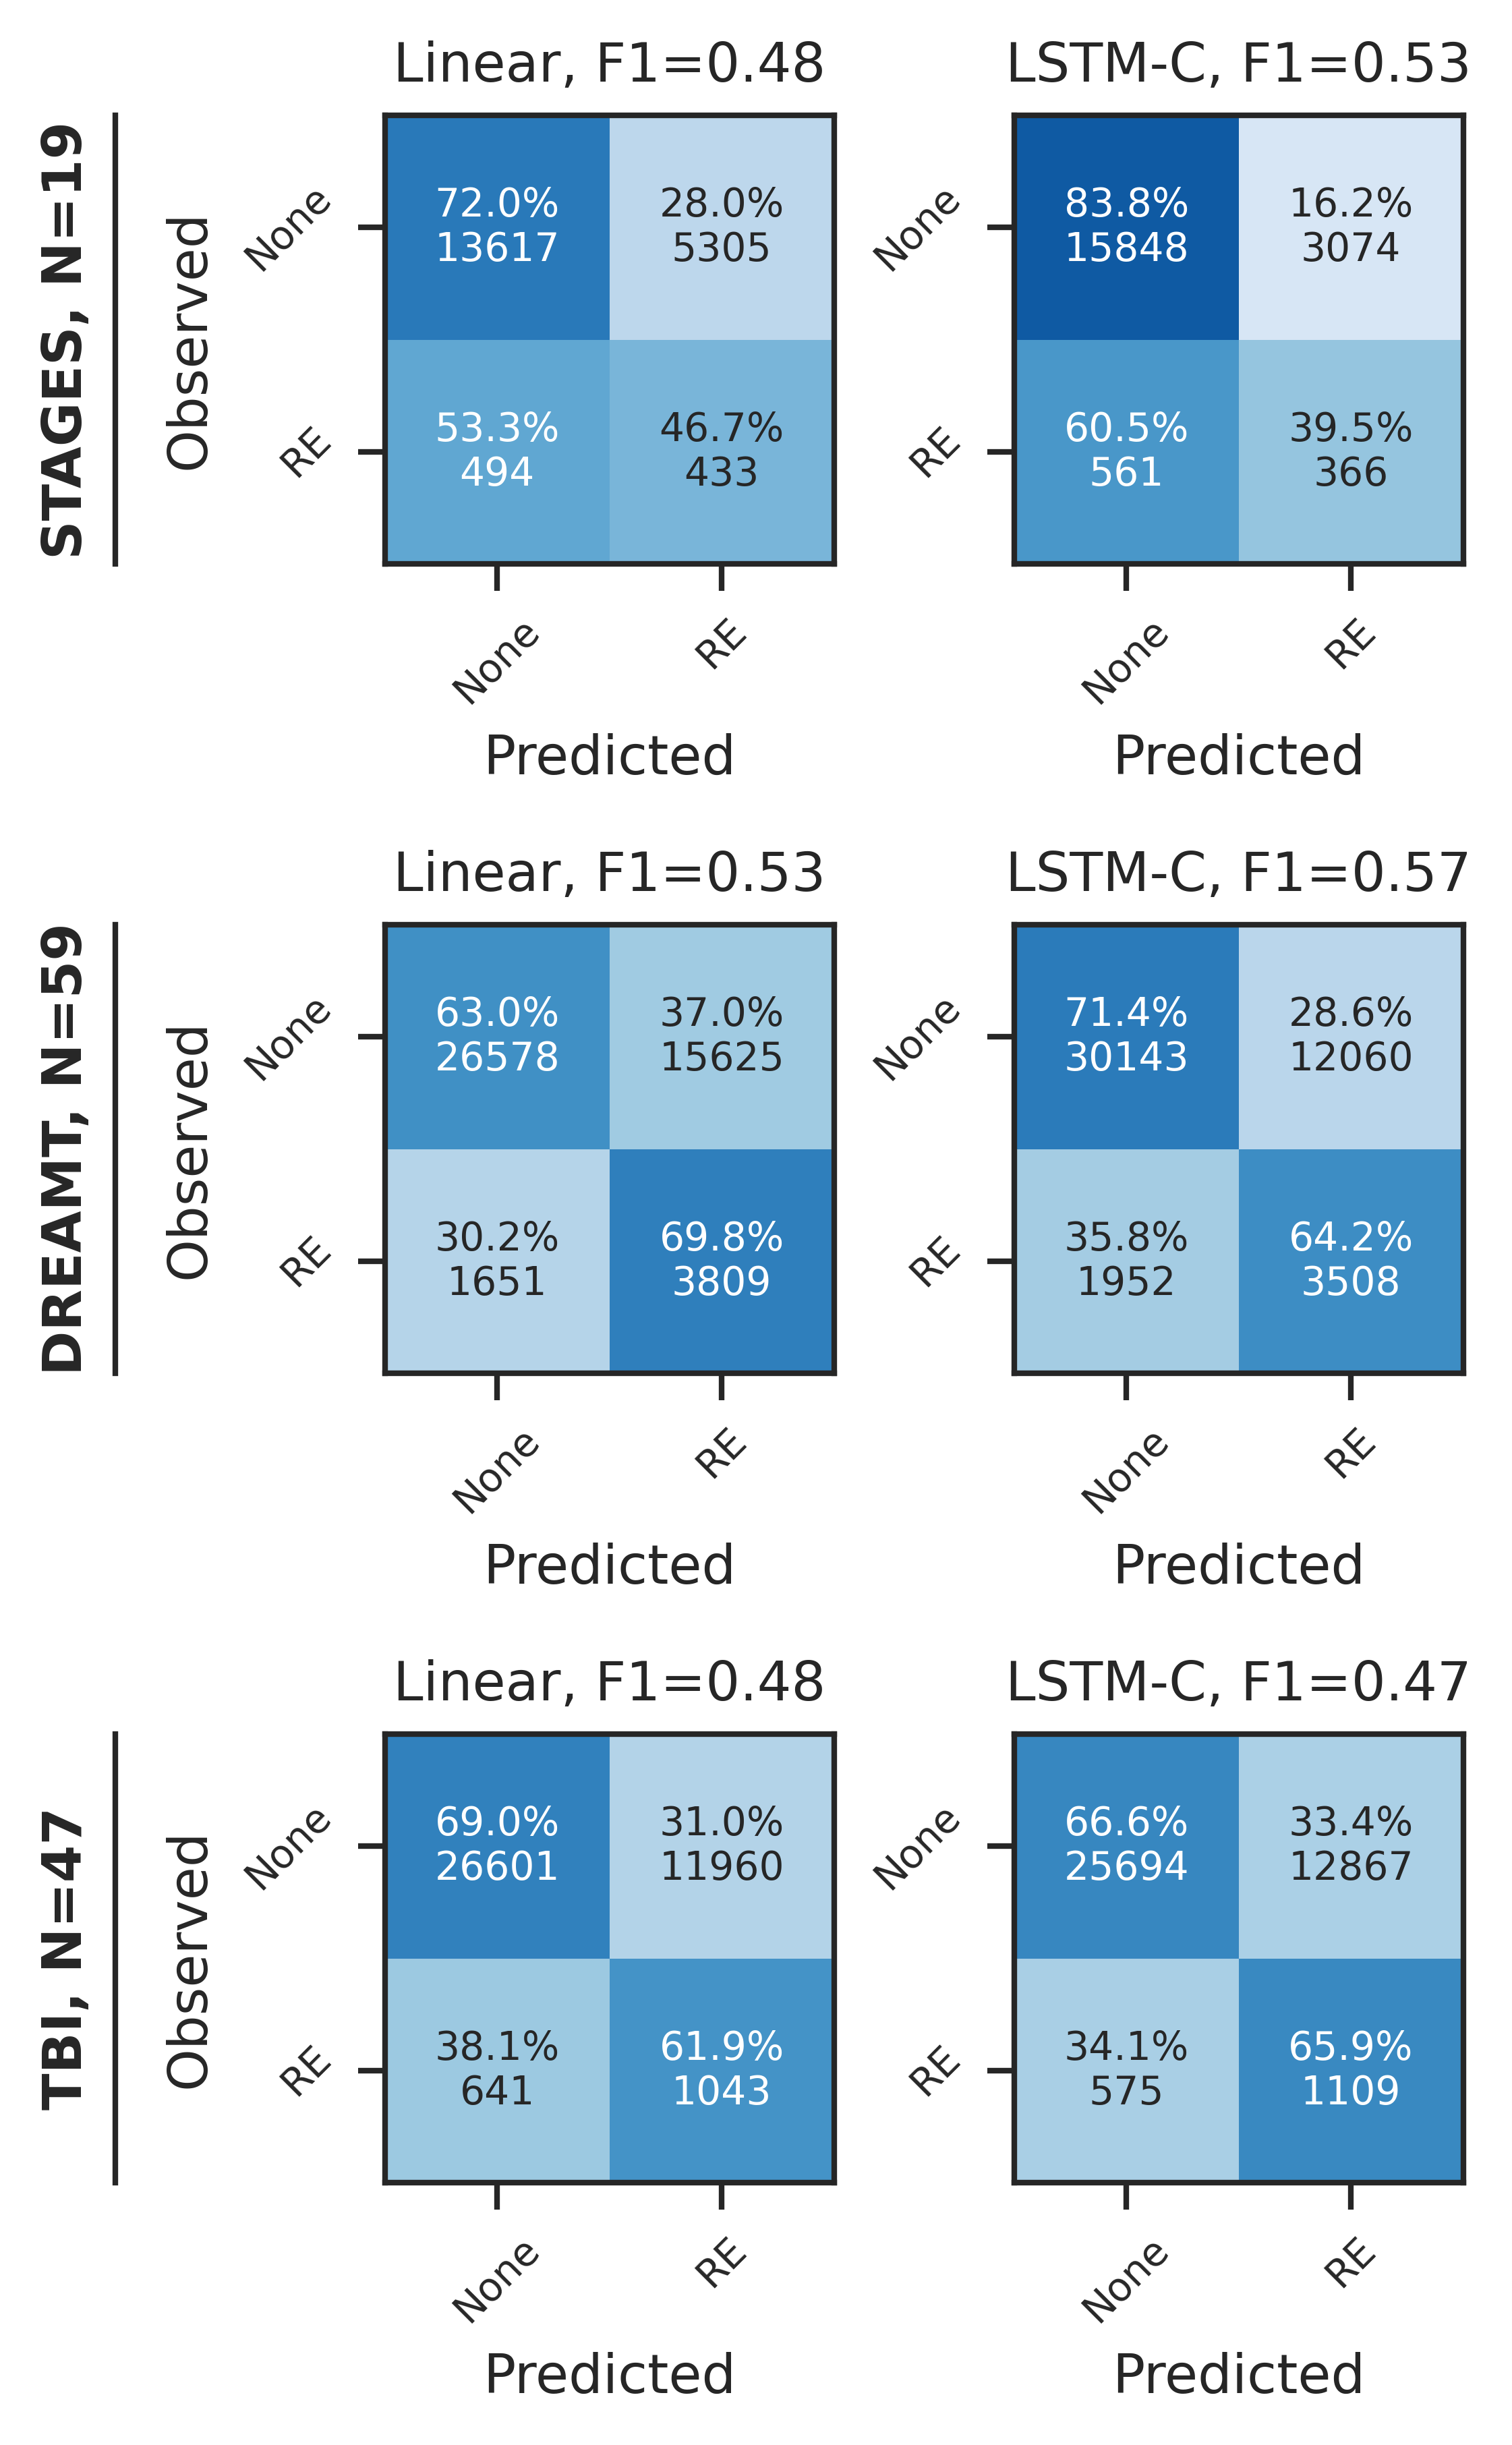

In [29]:
#Plot CM
sns.set_context("paper")
sns.set_style('ticks')
matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['font.family'] = 'sans-serif'

lin_preds = np.array(preds_all, dtype='O')[np.array(exp_i) == 'Linear']
lstmc_preds = np.array(preds_all, dtype='O')[np.array(exp_i) == 'LSTM-C']

lin_targets = np.array(targets_all, dtype='O')[np.array(exp_i) == 'Linear']
lstmc_targets = np.array(targets_all, dtype='O')[np.array(exp_i) == 'LSTM-C']

lin_dset = np.array(dataset_i)[np.array(exp_i) == 'Linear']
lstmc_dset = np.array(dataset_i)[np.array(exp_i) == 'LSTM-C']

lin_dict = {
    'title': 'Linear',
    'preds': lin_preds,
    'targets': lin_targets,
    'dset': lin_dset,
}
lstmc_dict = {
    'title': 'LSTM-C',
    'preds': lstmc_preds,
    'targets': lstmc_targets,
    'dset': lstmc_dset,
}

models =  [lin_dict, lstmc_dict]
fig, axes_2d = plt.subplots(3,2, dpi=600, figsize=(3.6,6),layout='constrained')

if experiment == '2c':
    lm = label_map_re
    lo = label_order_re
    ln = label_names_re
else:
    lm = label_map
    lo = label_order
    ln = label_names

for m, model in enumerate(models):
    axes = axes_2d[:,m].ravel()
    for i, dset in enumerate(dset_order_nomap):
        preds = model['preds'][model['dset']==dset]
        preds = np.concatenate(list(preds))
        targets = model['targets'][model['dset']==dset]
        targets = np.concatenate(list(targets))

        # Epoch-by-epoch confusion matrix
        # Switch label orders 
        idx_dict = {}
        for place, tag in enumerate(lo):
            idx_dict[place] = (
                targets == lm[tag],
                preds == lm[tag],
            )
        for place, (label_idx, pred_idx) in idx_dict.items():
            targets[label_idx] = place
            preds[pred_idx] = place


        ## Confusion Matrix
        cm_abs = confusion_matrix(targets, preds, normalize=None)
        cm_norm = cm_abs/cm_abs.sum(axis=1, keepdims=True)
        # Create combined annotation matrix
        annot = np.empty_like(cm_abs).astype(str)
        for r in range(cm_abs.shape[0]):
            for c in range(cm_abs.shape[1]):
                annot[r, c] = f"{cm_norm[r, c]*100:.1f}%\n{cm_abs[r, c]}"
        ax = sns.heatmap(
            cm_norm, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1, ax=axes[i],
            square=True, cbar=False, #linewidths=0.2, linecolor='black', clip_on=False,
            xticklabels=ln, yticklabels=ln,# annot_kws={'fontsize':7}
        )
        for _, spine in ax.spines.items():
            spine.set_visible(True)

        ax.tick_params(rotation = 45)
        ax.set_ylabel('Observed')
        for label in ax.get_yticklabels():
            label.set_verticalalignment('center')
            label.set_fontsize(7)
        ax.set_xlabel('Predicted')
        for label in ax.get_xticklabels():
            label.set_horizontalalignment('center')
            label.set_fontsize(7)

        if m == 0:
            sec = axes[i].secondary_yaxis(location=-0.6)
            sec.set_ylabel(f'{dset_order[i]}, N={sum(model['dset']==dset)}', fontweight='bold')
            sec.set_yticks([],[])
        else:
            ax.set_ylabel('')
        # if not i == 2:
        #     ax.set_xlabel('')
        ax.set_title(f'{model['title']}, F1={round(f1_score(targets,preds,average='macro'),2)}')

plt.show()



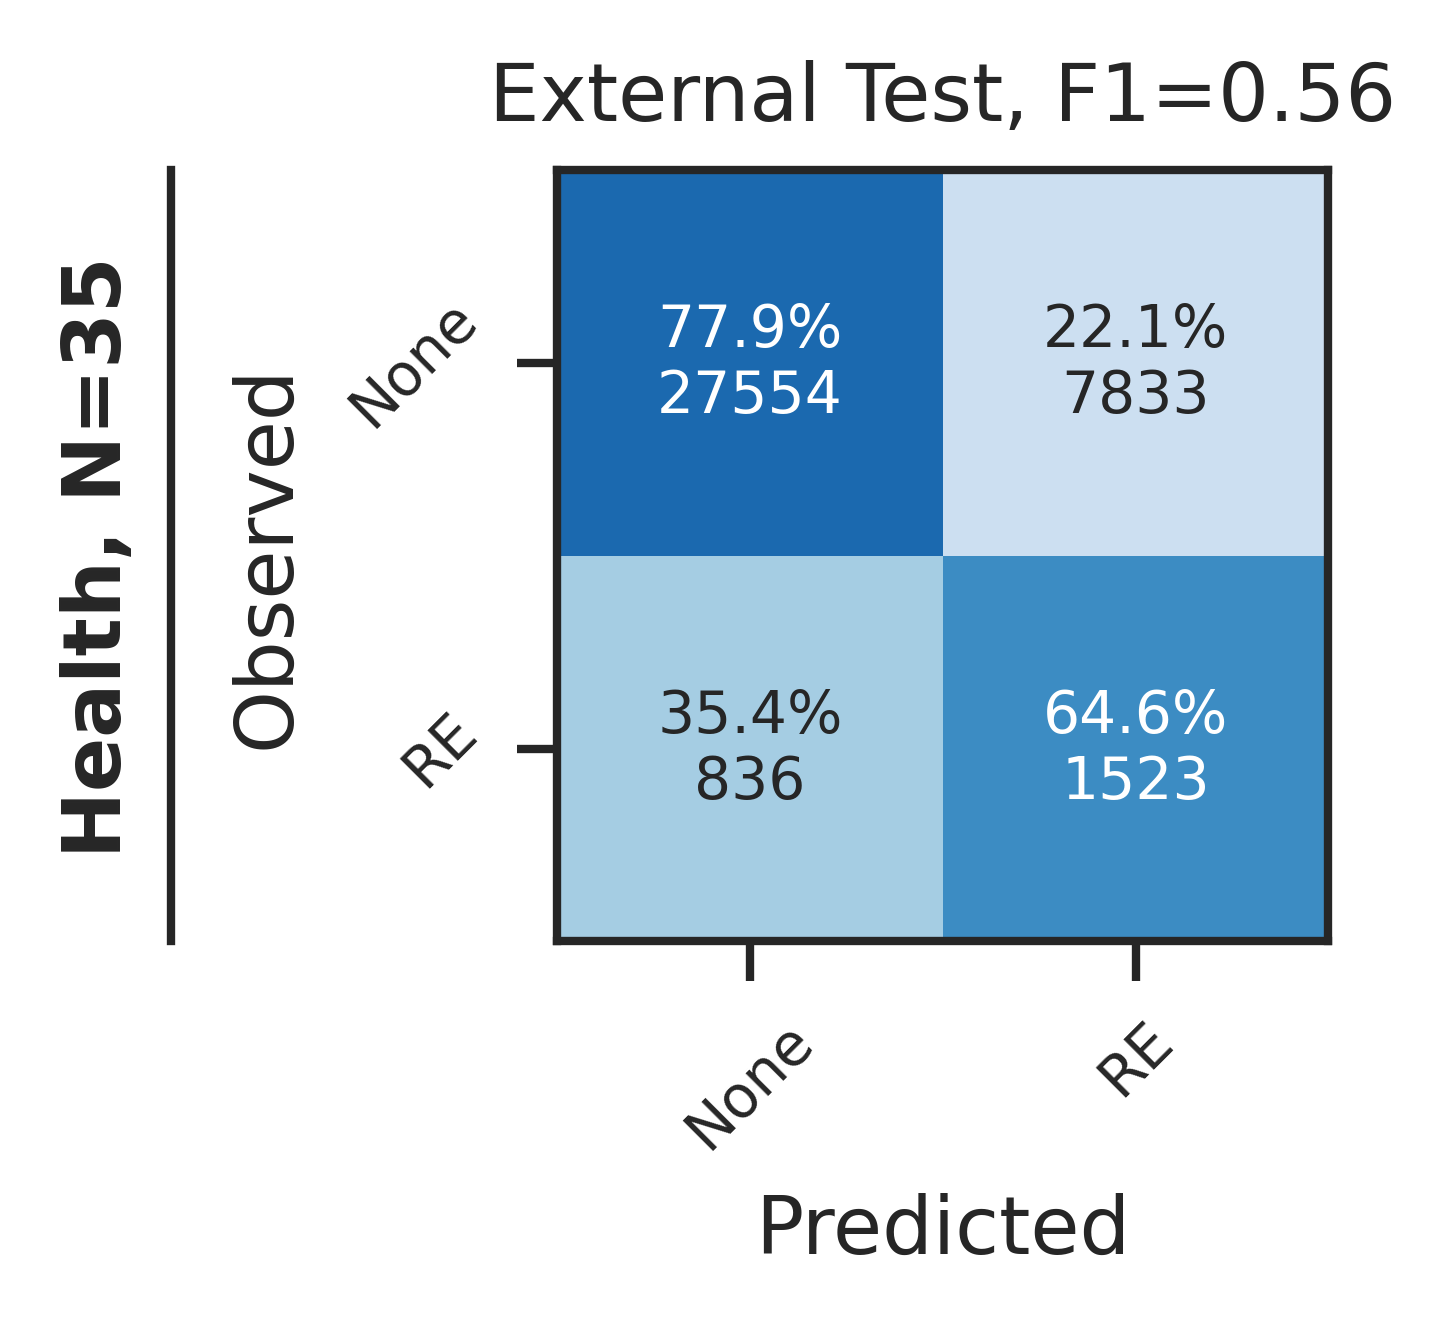

In [19]:
#Plot external test CM
sns.set_context("paper")
sns.set_style('ticks')
matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['font.family'] = 'sans-serif'

ext_dict = {
    'title': 'External Test',
    'preds': np.array(preds_all, dtype='O'),
    'targets': np.array(targets_all, dtype='O'),
    'dset': dataset_i,
}

models =  [ext_dict]
fig, axes = plt.subplots(1,1, dpi=600, figsize=(2,2),layout='constrained')


lm = label_map_re
lo = label_order_re
ln = label_names_re


for m, model in enumerate(models):
    preds = model['preds']
    preds = np.concatenate(list(preds))
    targets = model['targets']
    targets = np.concatenate(list(targets))

    # Epoch-by-epoch confusion matrix
    # Switch label orders 
    idx_dict = {}
    for place, tag in enumerate(lo):
        idx_dict[place] = (
            targets == lm[tag],
            preds == lm[tag],
        )
    for place, (label_idx, pred_idx) in idx_dict.items():
        targets[label_idx] = place
        preds[pred_idx] = place


    ## Confusion Matrix
    cm_abs = confusion_matrix(targets, preds, normalize=None)
    cm_norm = cm_abs/cm_abs.sum(axis=1, keepdims=True)
    # Create combined annotation matrix
    annot = np.empty_like(cm_abs).astype(str)
    for r in range(cm_abs.shape[0]):
        for c in range(cm_abs.shape[1]):
            annot[r, c] = f"{cm_norm[r, c]*100:.1f}%\n{cm_abs[r, c]}"
    ax = sns.heatmap(
        cm_norm, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1, ax=axes,
        square=True, cbar=False, #linewidths=0.2, linecolor='black', clip_on=False,
        xticklabels=ln, yticklabels=ln,# annot_kws={'fontsize':7}
    )
    for _, spine in ax.spines.items():
        spine.set_visible(True)

    ax.tick_params(rotation = 45)
    ax.set_ylabel('Observed')
    for label in ax.get_yticklabels():
        label.set_verticalalignment('center')
        label.set_fontsize(7)
    ax.set_xlabel('Predicted')
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('center')
        label.set_fontsize(7)

    if m == 0:
        sec = axes.secondary_yaxis(location=-0.5)
        sec.set_ylabel(f'Health, N={len(model['dset'])}', fontweight='bold')
        sec.set_yticks([],[])
    else:
        ax.set_ylabel('')
    # if not i == 2:
    #     ax.set_xlabel('')
    ax.set_title(f'{model['title']}, F1={round(f1_score(targets,preds,average='macro'),2)}')

plt.show()



In [40]:
def apno_plot(
    targets,
    preds,
    soft_preds,
    yhat_aligned,
    accelerometry,
    label_map: dict,
    label_order: list,
    colormap: dict):
    # Plots for Sleep stage model
    fig, axes = plt.subplots(5,1, dpi=600, figsize=(7.1,6.3), layout='constrained', sharex=True, height_ratios=[1,1,1,2,1])

    # targets[targets==ss_label_map['missing']] *= np.nan
    axes[0].set_title('Respiratory Events')
    axes[0].plot(targets)
    axes[0].set_yticks(np.arange(len(label_order)), labels=label_order)

    axes[1].set_title('Estimated Respiratory Events')
    axes[1].plot(preds)
    axes[1].set_yticks(np.arange(len(label_order)), labels=label_order)

    axes[2].set_title('Estimated Probabilities')
    base = np.zeros(len(soft_preds))
    x = np.arange(len(soft_preds))

    for event in label_order:
        idx = label_map[event]
        axes[2].fill_between(x, base, soft_preds[:,idx]+base, label = event, color = colormap[event])
        base = base + soft_preds[:,idx]
    handles, labels = axes[2].get_legend_handles_labels()
    axes[2].set_ylabel(r'P(RE|D,$\theta$)')
    axes[2].set_ylim(0,1)

    axes[3].legend(handles[::-1], labels[::-1], loc = 'upper right')
    axes[3].set_title('Respiratory Event Estimations Across Context Windows')
    nan_mask = np.isnan(yhat_aligned[:,:,0])
    seq_hyp = yhat_aligned.argmax(axis=-1)
    seq_hyp[nan_mask] -= 1
    cmap = ['black']
    cml = list(colormap.values())
    cmap.extend(cml)
    cmap = cl.ListedColormap(cmap)#['black', 'white', 'tab:olive', 'tab:purple'])
    axes[3].imshow(seq_hyp,cmap=cmap, aspect='auto')
    axes[3].set_ylabel('Context window')

    axes[4].plot(np.linspace(0,len(preds), len(accelerometry)), accelerometry)
    axes[4].set_xlim(0,len(preds))
    axes[4].set_ylim(-2.1,2.1)
    axes[4].set_ylabel('g')
    axes[4].set_xlabel('Epoch')
    axes[4].set_title('Input Tri-Axial Accelerometry')
    return fig, axes

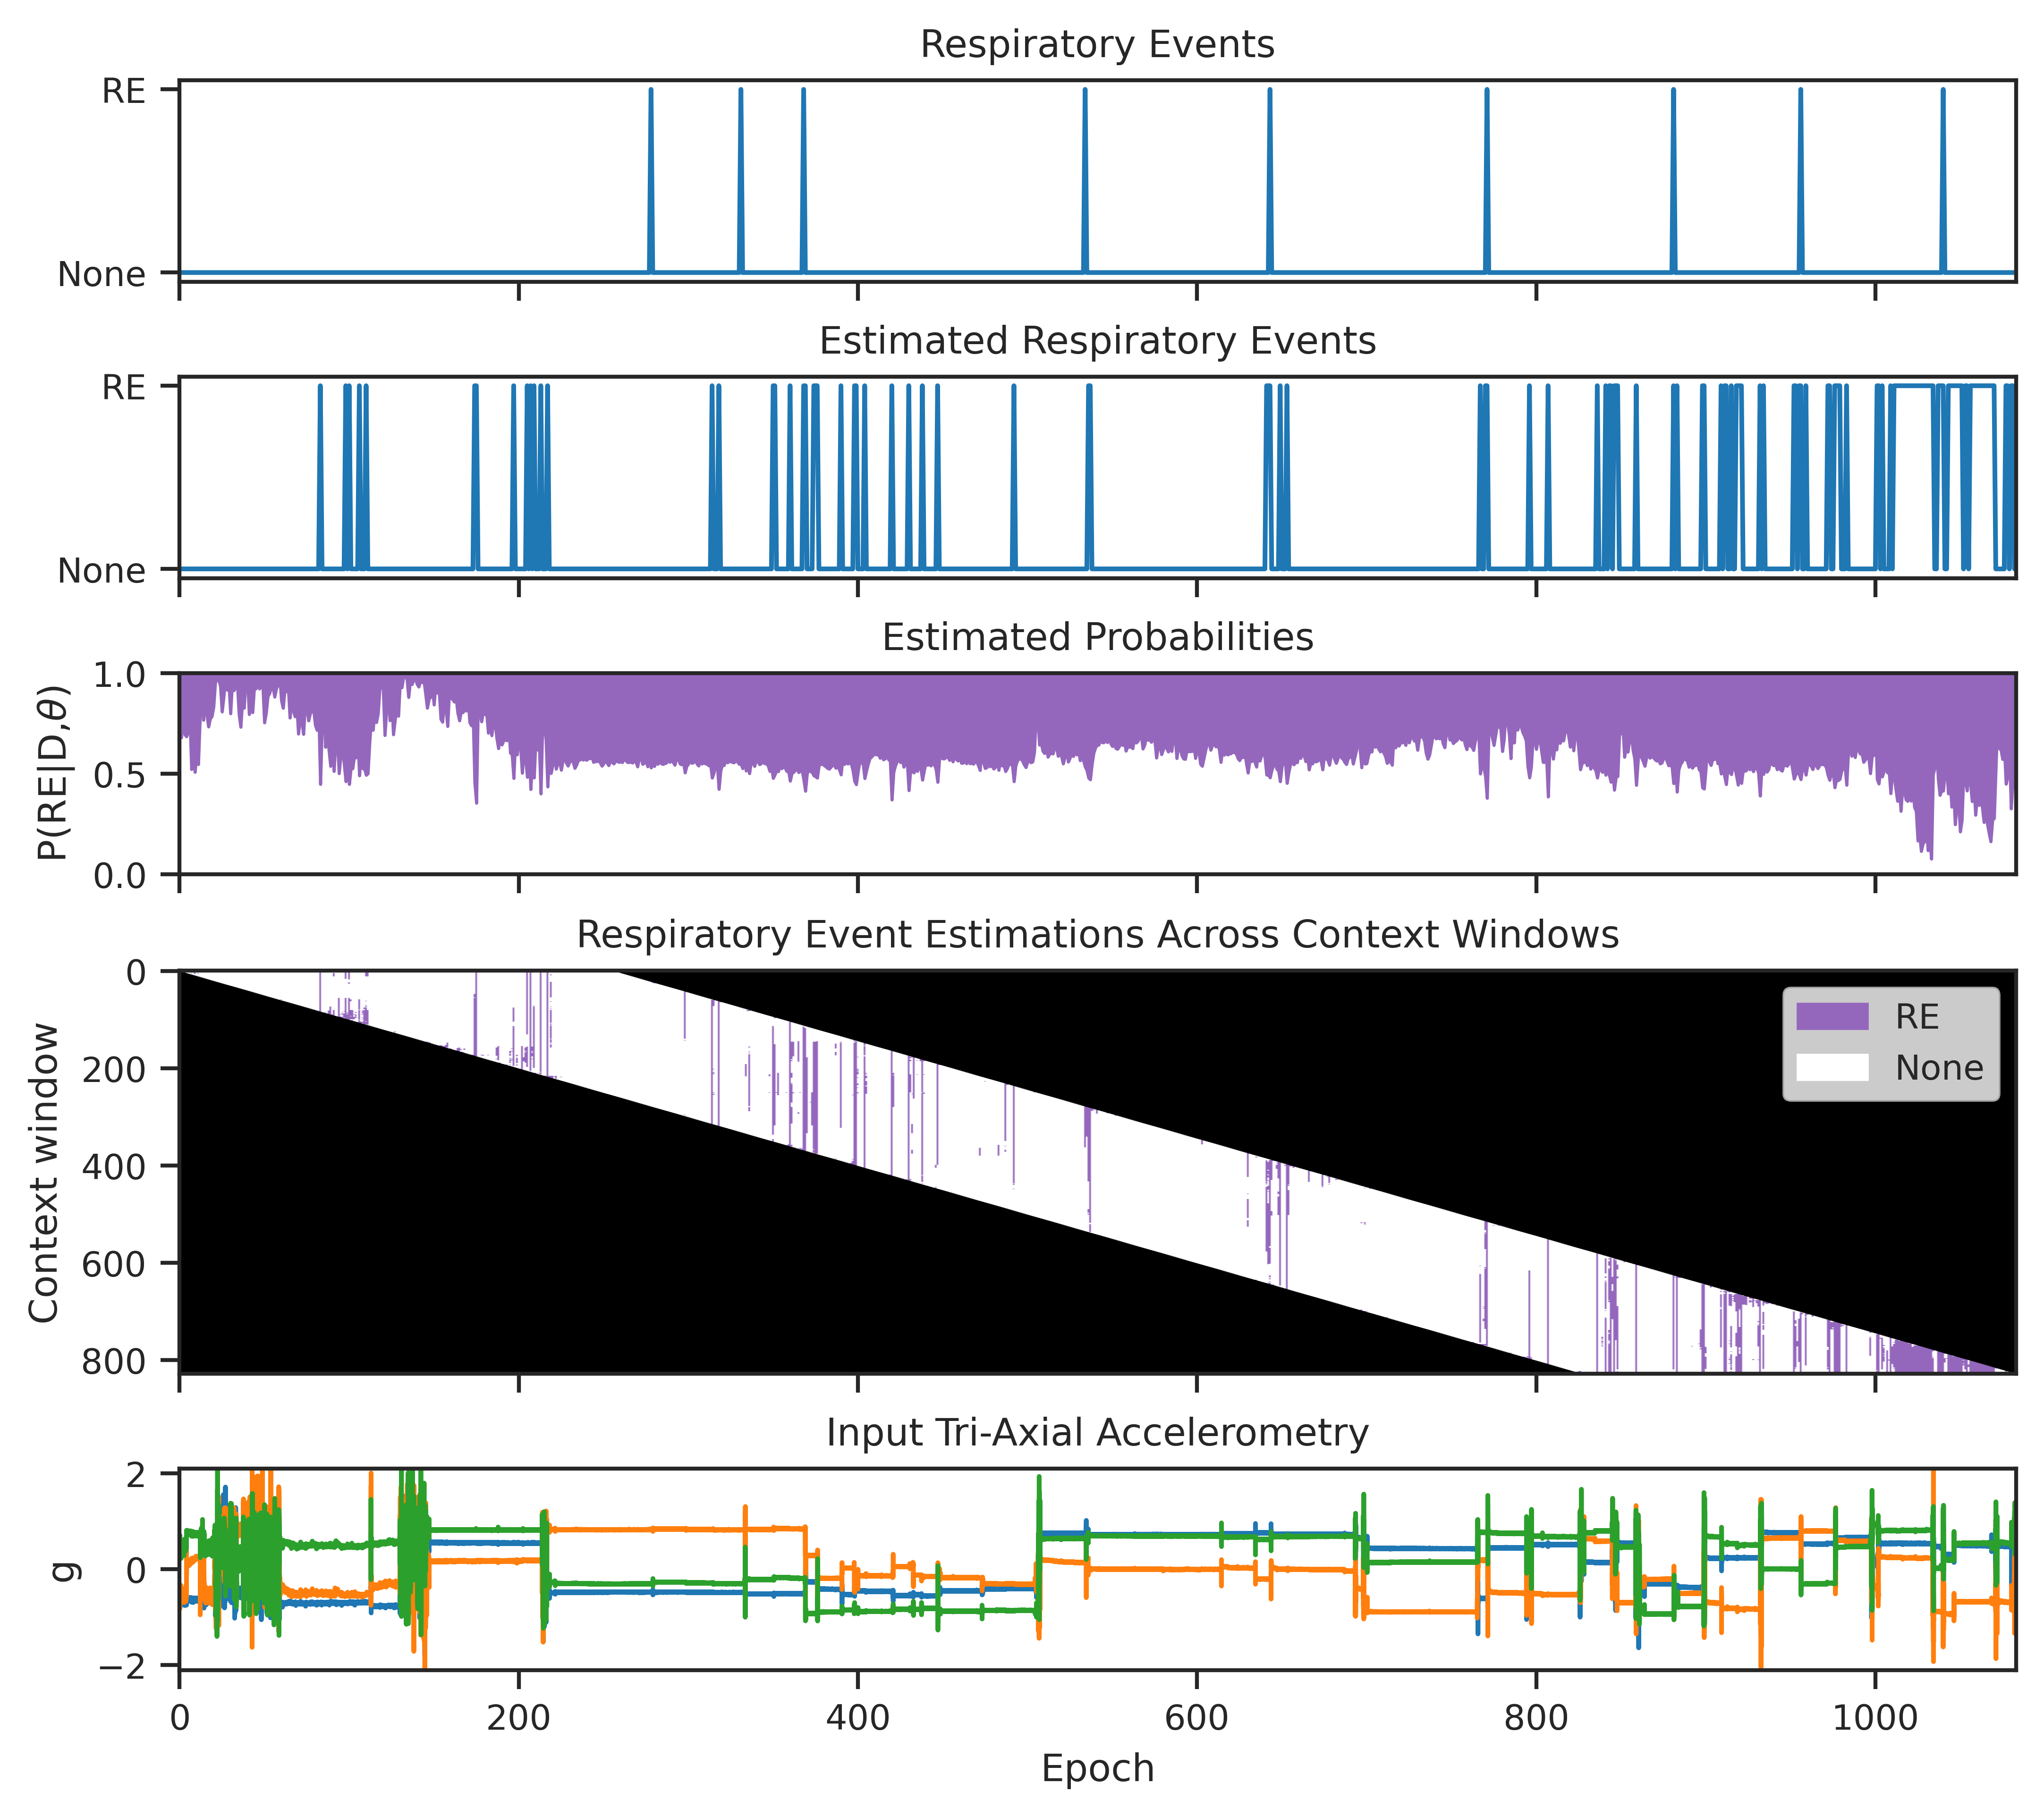

In [41]:
paths = {
    'TBI': '/oak/stanford/groups/mignot/projects/actigraphy_fm/data/tbi/',
    'Health': '/oak/stanford/groups/mignot/projects/actigraphy_fm/data/amazfit/',
    'DREAMT': '/oak/stanford/groups/mignot/projects/actigraphy_fm/data/dreamt/',
    'STAGES': '/oak/stanford/groups/mignot/projects/actigraphy_fm/data/stages/',
    'Newcastle L': '/oak/stanford/groups/mignot/projects/actigraphy_fm/data/newcastle_left/',
    'Newcastle R': '/oak/stanford/groups/mignot/projects/actigraphy_fm/data/newcastle_right/',
    'sleepaccel': '/oak/stanford/groups/mignot/projects/actigraphy_fm/data/sleepaccel/',
}

# if experiment == '2c':
lm = label_map_re
lo = label_order_re
ln = label_names_re
cm = colormap_re
# else:
#     lm = label_map
#     lo = label_order
#     ln = label_names
#     cm = colormap

quantile = 0.50
dataset = 'Health'
subidx_macro_results = macro_results.copy()
subidx_macro_results['dataset'] = dataset_i
subidx_macro_results['dataset'] = subidx_macro_results['dataset'].map(dset_map)
subidx_macro_results['subject'] = subject_i
subidx_macro_results = subidx_macro_results.set_index('subject')
subidx_macro_results = subidx_macro_results.loc[subidx_macro_results['dataset']==dataset]
quantile_sub = subidx_macro_results.sort_values(by='F1').iloc[int(len(subidx_macro_results)*quantile)+1].name

# for exp in (lmstc_apnea_path, lin_apnea_path):
exp = external_apnea_path
sub_h5 = paths[dataset] + quantile_sub + '.h5'
results_path = f'{exp}/amazfit/'#{dataset.lower()}/'

data = h5_to_dict(sub_h5)
sub_dir = results_path + quantile_sub

targets = np.load(os.path.join(sub_dir + '/targets.npy'))
scores = np.load(os.path.join(sub_dir + '/soft_preds.npy'))
scores_aligned = np.load(os.path.join(sub_dir + '/y_hat_aligned.npy'))

preds = scores.argmax(axis=-1)

# Reorder labels and preds for plotting

idx_dict = {}
for place, tag in enumerate(lo):
    idx_dict[place] = (
        targets == lm[tag],
        preds == lm[tag],
    )
for place, (label_idx, pred_idx) in idx_dict.items():
    targets[label_idx] = place
    preds[pred_idx] = place

# Plot apnogram
fig, axes = apno_plot(
    targets, preds, scores, scores_aligned,
    data['accelerometry'].T,
    label_map = lm,
    label_order = lo,
    colormap = cm,
)

# fig.suptitle()
plt.show()

In [28]:
# Load regression model results
results = defaultdict(list)

experiment = 
for dataset in os.scandir(exp_dir):
    for sub_dir in os.scandir(dataset):
        results['subject'].append(os.path.basename(sub_dir))
        results['dataset'].append(os.path.basename(dataset))

        sub_h5 = paths[dset_map[os.path.basename(dataset)]] + os.path.basename(sub_dir) + '.h5'

        with h5py.File(sub_h5, 'r') as f:
            results['AHI'].append(f.attrs['ahi'])
            # apneas = np.array(f['annotations/apnea'])
